# Read Halo Catalog from Abacus CompaSO

Refer to https://abacusutils.readthedocs.io/en/latest/compaso.html

Make sure your version of abacusutils:

In [1]:
import sys, os
sys.path.insert(0, os.path.expanduser('~/lib/'))
import abacusnbody
abacusnbody.__file__

'/global/u1/s/siyizhao/lib/abacusutils/abacusnbody/__init__.py'

## Read the Halos

In [2]:
from abacusnbody.data.compaso_halo_catalog import CompaSOHaloCatalog

In [3]:
sim_dir = '/global/cfs/projectdirs/desi/cosmosim/Abacus/'
sim_names = ['Abacus_pngbase_c302_ph000', 'Abacus_pngbase_c300_ph000']#, 'Abacus_pngbase_c301_ph000', 'Abacus_pngbase_c303_ph000']
labels = ['fNL=100', 'fNL=30'] #, 'fNL=-30', 'fNL=-100']
z = 2.5

In [4]:
import abacusnbody.metadata
meta = abacusnbody.metadata.get_meta('AbacusSummit_base_c000_ph000', redshift=z)
m_p = meta['ParticleMassHMsun'] # Particle mass in h^-1 Msun
print(f'Particle mass in AbacusSummit: {m_p:.3e} h^-1 Msun')
m_p *= 6912**3/4096**3 # pngbase has lower resolution
print(f'Particle mass in Abacus_pngbase: {m_p:.3e} h^-1 Msun')

Particle mass in AbacusSummit: 2.109e+09 h^-1 Msun
Particle mass in Abacus_pngbase: 1.014e+10 h^-1 Msun


/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/asdf/_asdf.py:375: AsdfWarning: File 'file:///global/u1/s/siyizhao/lib/abacusutils/abacusnbody/metadata/abacussummit_headers_compressed.asdf' was created with extension URI 'asdf://abacusnbody.org/extensions/abacus-0.0.1' (from package abacusutils==1.3.1.dev24+g597cea9), but older package (abacusutils==0.1.dev746+gb7ad61d21.d20251121) is installed.
  warnings.warn(msg, AsdfWarning)
/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/asdf/_asdf.py:375: AsdfWarning: File 'file:///global/u1/s/siyizhao/lib/abacusutils/abacusnbody/metadata/abacusdesi2_headers_compressed.asdf' was created with extension URI 'asdf://abacusnbody.org/extensions/abacus-0.0.1' (from package abacusutils==1.3.1.dev88+gfe21a4d), but older package (abacusutils==0.1.dev746+gb7ad61d21.d20251121) is installed.
  warnings.warn(msg, AsdfWarning)


In [5]:
def masked_non_positive_Np(Np):
    # remove zeros and any non-positive entries from halo_masses
    mask = Np > 0
    n_removed = Np.size - mask.sum()
    if n_removed:
        print(f"Removed {n_removed} non-positive halo masses")

    Np_masked = Np[mask]
    return Np_masked


In [6]:
def read_halo_mass(sim_name):
    cat = CompaSOHaloCatalog(sim_dir+sim_name+f'/halos/z{z:.3f}', fields=['N'])
    Np = cat.halos['N']
    Np = masked_non_positive_Np(Np)
    hm = Np * m_p
    return hm

In [7]:
def read_halo_xv_mass(sim_name, return_table=False):
    '''
    Read halo positions, velocities, and masses from Abacus CompaSO halo catalog,
    if return_table is True, return cat.halos, else return pos, vel, mass
    '''
    cat = CompaSOHaloCatalog(sim_dir+sim_name+f'/halos/z{z:.3f}', fields=['N','x_com','v_com'])
    if return_table:
        return cat.halos
    else:
        Np = cat.halos['N']
        pos = cat.halos['x_com']
        vel = cat.halos['v_com']
        return pos, vel, Np

## Plot Halo Mass Function

In [8]:
import numpy as np
from matplotlib import pyplot as plt

/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/asdf/_asdf.py:375: AsdfWarning: File 'file:///global/cfs/projectdirs/desi/cosmosim/Abacus/Abacus_pngbase_c302_ph000/halos/z2.500/halo_info/halo_info_000.asdf' was created with extension URI 'asdf://abacusnbody.org/extensions/abacus-0.0.1' (from package abacusutils==1.3.1.dev184+g786cf42), but older package (abacusutils==0.1.dev746+gb7ad61d21.d20251121) is installed.
  warnings.warn(msg, AsdfWarning)
/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/asdf/_asdf.py:375: AsdfWarning: File 'file:///global/cfs/projectdirs/desi/cosmosim/Abacus/cleaning/Abacus_pngbase_c302_ph000/z2.500/cleaned_halo_info/cleaned_halo_info_000.asdf' was created with extension URI 'asdf://abacusnbody.org/extensions/abacus-0.0.1' (from package abacusutils==1.3.1.dev184+g786cf42), but older package (abacusutils==0.1.dev746+gb7ad61d21.d20251121) is installed.
  warning

Removed 37057 non-positive halo masses


/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/asdf/_asdf.py:375: AsdfWarning: File 'file:///global/cfs/projectdirs/desi/cosmosim/Abacus/Abacus_pngbase_c300_ph000/halos/z2.500/halo_info/halo_info_000.asdf' was created with extension URI 'asdf://abacusnbody.org/extensions/abacus-0.0.1' (from package abacusutils==1.3.1.dev184+g786cf42), but older package (abacusutils==0.1.dev746+gb7ad61d21.d20251121) is installed.
  warnings.warn(msg, AsdfWarning)
/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/asdf/_asdf.py:375: AsdfWarning: File 'file:///global/cfs/projectdirs/desi/cosmosim/Abacus/cleaning/Abacus_pngbase_c300_ph000/z2.500/cleaned_halo_info/cleaned_halo_info_000.asdf' was created with extension URI 'asdf://abacusnbody.org/extensions/abacus-0.0.1' (from package abacusutils==1.3.1.dev184+g786cf42), but older package (abacusutils==0.1.dev746+gb7ad61d21.d20251121) is installed.
  warning

Removed 34208 non-positive halo masses


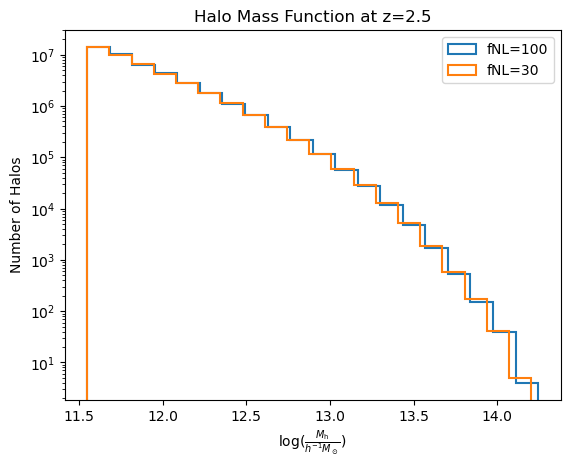

In [9]:
for sim_name, label in zip(sim_names, labels):
    mass = read_halo_mass(sim_name)
    plt.hist(np.log10(mass), bins=20, label=label, histtype='step', linewidth=1.5)
plt.yscale('log')
plt.xlabel(r'$\log(\frac{M_{\rm h}}{h^{-1} M_\odot})$')
plt.ylabel('Number of Halos')
plt.title(f'Halo Mass Function at z={z}')
plt.legend()
plt.show()